# Taller: Modelos de Clasificación - Predicción de Envíos en E-Commerce
 
En este notebook encontrarán la estructura general para desarrollar el modelo predictivo de retrasos en los envíos. Sigan las instrucciones de cada sección y completen el código correspondiente.

In [100]:
# Paso 0: Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix

# TIP: Asegúrense de importar aquí los tres clasificadores de scikit-learn que elijan probar,
# junto con las métricas de evaluación (accuracy_score, confusion_matrix, etc.)

## 1. Carga de Datos y Análisis Exploratorio Inicial

Los datos para realizar el ejercicio se encuentran aqui: [E-Commerce Shipping Data](https://www.kaggle.com/datasets/prachi13/customer-analytics)

In [49]:
# Paso 1: Usa pandas para cargar el dataset descargado de Kaggle

data = pd.read_csv("Train.csv")

data.info()

# TIP: Exploren las primeras filas con .head(), verifiquen los tipos de datos con .info()
# y revisen si existen valores nulos antes de avanzar.


<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB


In [50]:
data.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


## 2. Preprocesamiento de Datos e Ingeniería de Características
En esta sección deben transformar las variables categóricas en formatos numéricos aptos para los modelos.

In [ ]:
#Paso 2: Identificación y transformación de variables categóricas

# TIP 1 (Encoding Ordinal): Analicen la columna 'Product_importance'. ¿Tiene un orden lógico?
# Apliquen una estrategia que conserve esa jerarquía (ej. low=1, medium=2, high=3).

# TIP 2 (One-Hot Encoding): Analicen las columnas 'Mode_of_Shipment' y 'Warehouse_block'.
# Al no tener un orden lógico, utilicen One-Hot Encoding (pd.get_dummies o OneHotEncoder).

# TIP 3: Recuerden definir claramente su matriz de características (X) y el vector objetivo (y).
# El target para este problema es la columna 'Reached.on.Time_Y.N'.

In [51]:
data['Product_importance'].value_counts()

Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64

In [52]:
data['Product_importance'] = data['Product_importance'].map({'low': 1, 'medium': 2, 'high': 3})
data_new = data
data_new

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,1,F,44,1233,1
1,2,F,Flight,4,5,216,2,1,M,59,3088,1
2,3,A,Flight,2,2,183,4,1,M,48,3374,1
3,4,B,Flight,3,3,176,4,2,M,10,1177,1
4,5,C,Flight,2,2,184,3,2,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,2,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,2,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,1,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,2,M,2,1210,0


In [53]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
X_Transform = enc.fit(data_new[['Mode_of_Shipment','Warehouse_block','Gender']])

In [69]:
X = data_new.merge(pd.DataFrame(X_Transform.transform(data_new[['Mode_of_Shipment','Warehouse_block','Gender']]),columns=enc.get_feature_names_out()),left_index=True, right_index=True)

In [70]:
X = X.drop(['ID','Warehouse_block','Mode_of_Shipment','Gender','Reached.on.Time_Y.N'], axis=1 )
Y = data['Reached.on.Time_Y.N']

## 3. División del Dataset
Separación de los datos en conjuntos de entrenamiento y prueba.

In [ ]:
# Paso 3: Train/Test Split
# TIP: Utilicen train_test_split de sklearn. Configuren un test_size adecuado (ej. 15% o 20%)
# y un random_state fijo para que sus resultados sean replicables.

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42, stratify=Y)

## 4. Entrenamiento de Modelos
 
Deben seleccionar, entrenar y evaluar tres algoritmos de clasificación distintos (por ejemplo: Regresión Logística, Árboles de Decisión, Random Forest, KNN, etc.).

              precision    recall  f1-score   support

           0       0.55      0.53      0.54       887
           1       0.69      0.71      0.70      1313

    accuracy                           0.64      2200
   macro avg       0.62      0.62      0.62      2200
weighted avg       0.63      0.64      0.63      2200



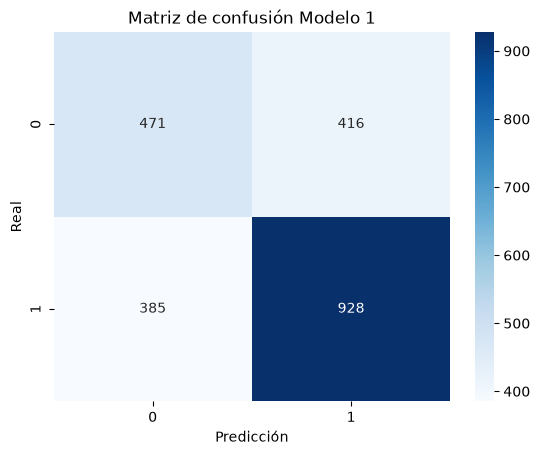

In [108]:
## Paso 4: Entrenamiento y evaluación de modelos

# Modelo 1: Instanciar, entrenar con datos de train y predecir con datos de test

from sklearn import tree
Modelo_1 = tree.DecisionTreeClassifier()
Modelo_1.fit(X_train, y_train)

y_pred = Modelo_1.predict(X_test)


print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusión Modelo 1')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


              precision    recall  f1-score   support

           0       0.56      0.70      0.62       887
           1       0.75      0.62      0.68      1313

    accuracy                           0.65      2200
   macro avg       0.66      0.66      0.65      2200
weighted avg       0.67      0.65      0.66      2200



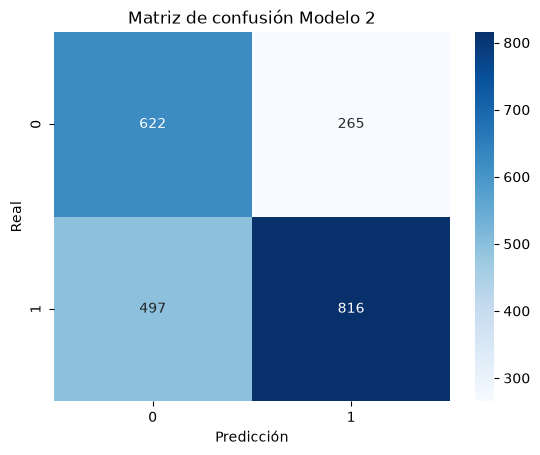

In [97]:
# Modelo 2: Instanciar, entrenar con datos de train y predecir con datos de test

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
Modelo_2 = RandomForestClassifier()
Modelo_2.fit(X_train, y_train)

y_pred = Modelo_2.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusión Modelo 2')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

              precision    recall  f1-score   support

           0       0.56      0.61      0.58       887
           1       0.72      0.67      0.69      1313

    accuracy                           0.65      2200
   macro avg       0.64      0.64      0.64      2200
weighted avg       0.65      0.65      0.65      2200



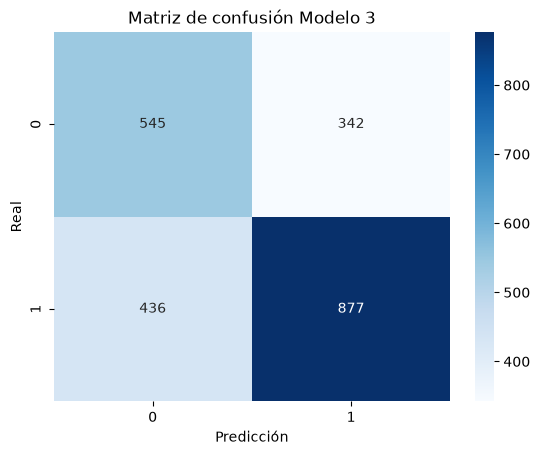

In [99]:
# Modelo 3: Instanciar, entrenar con datos de train y predecir con datos de test

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

Modelo_3 = KNeighborsClassifier(n_neighbors=5)
Modelo_3.fit(X_train, y_train)

y_pred = Modelo_3.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión Modelo 3')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

## 5. Evaluación y Comparación de Resultados
Generen las métricas y las gráficas solicitadas para contrastar el rendimiento de los tres modelos.

In [ ]:
# Paso 5: Cálculo de métricas para cada modelo por medio de accuracy_score, confusion_matrix, classification_report, etc.
# TIP: Almacenen los resultados de Accuracy en un diccionario o DataFrame para facilitar la graficación.

y_pred_1 = Modelo_1.predict(X_test)
y_pred_2 = Modelo_2.predict(X_test)
y_pred_3 = Modelo_3.predict(X_test)

acc_1 = accuracy_score(y_test, y_pred_1)
acc_2 = accuracy_score(y_test, y_pred_2)
acc_3 = accuracy_score(y_test, y_pred_3)

modelos = {
    'Decision Tree': (Modelo_1, y_pred_1),
    'Random Forest': (Modelo_2, y_pred_2),
    'KNN': (Modelo_3, y_pred_3),
}

for nombre, (_, pred) in modelos.items():
  print(f'=== Reporte de Clasificación: {nombre} ===')
  print(classification_report(y_test, pred))
  print('-' * 50)

df_accuracy = pd.DataFrame({
    'Modelo': ['Decision Tree', 'Random Forest', 'KNN'],
    'Accuracy': [acc_1, acc_2, acc_3],
})

print('\nResumen de Accuracy:')
print(df_accuracy)

=== Reporte de Clasificación: Decision Tree ===
              precision    recall  f1-score   support

           0       0.56      0.55      0.56       887
           1       0.70      0.71      0.71      1313

    accuracy                           0.65      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.65      0.65      2200

--------------------------------------------------
=== Reporte de Clasificación: Random Forest ===
              precision    recall  f1-score   support

           0       0.56      0.70      0.62       887
           1       0.75      0.62      0.68      1313

    accuracy                           0.65      2200
   macro avg       0.66      0.66      0.65      2200
weighted avg       0.67      0.65      0.66      2200

--------------------------------------------------
=== Reporte de Clasificación: KNN ===
              precision    recall  f1-score   support

           0       0.56      0.61      0.58       887
 

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13988\4265739452.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


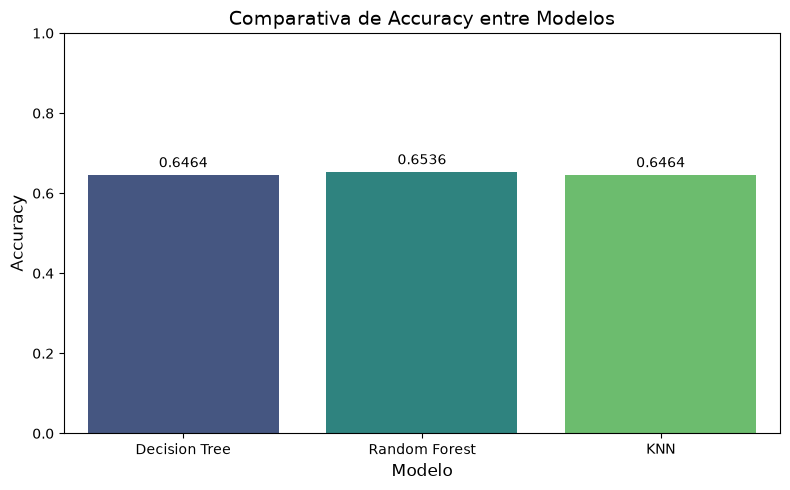

In [104]:
# Paso 6: Gráfica comparativa de Accuracy
# TIP: Utilicen un gráfico de barras (sns.barplot o plt.bar) donde el eje X sean los modelos
# y el eje Y sea el valor de Accuracy obtenido.

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x='Modelo', y='Accuracy', data=df_accuracy, palette='viridis'
)

plt.title('Comparativa de Accuracy entre Modelos', fontsize=14)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1.0)  # Escala de 0 a 1 para visualizar el porcentaje

# Añadir el valor numérico sobre cada barra
for p in ax.patches:
  ax.annotate(
      f'{p.get_height():.4f}',
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha='center',
      va='bottom',
      xytext=(0, 3),
      textcoords='offset points',
  )

plt.tight_layout()
plt.show()

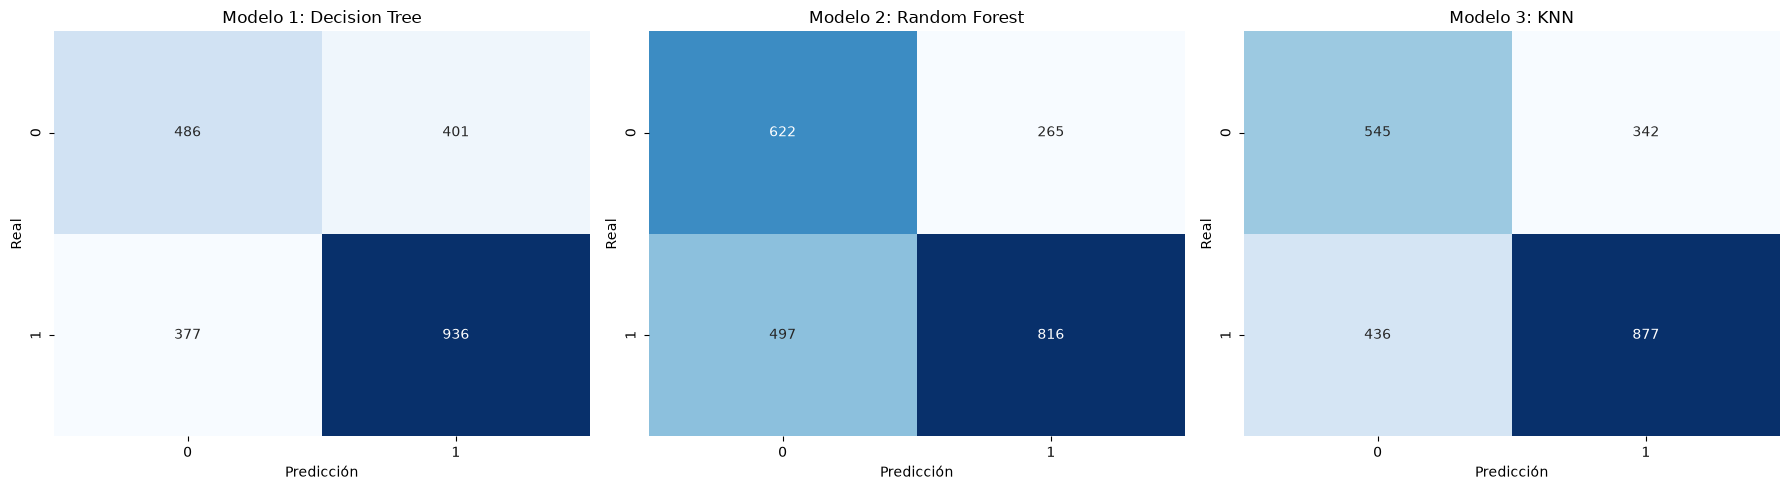

In [106]:
# Paso 7: Matrices de Confusión
# TIP: Generen y visualicen la matriz de confusión para cada uno de los tres modelos utilizando sns.heatmap.
# Esto les permitirá analizar visualmente los falsos positivos y falsos negativos de cada algoritmo.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

precisiones = [
    ('Modelo 1: Decision Tree', y_pred_1),
    ('Modelo 2: Random Forest', y_pred_2),
    ('Modelo 3: KNN', y_pred_3),
]

for idx, (titulo, pred) in enumerate(precisiones):
  cm = confusion_matrix(y_test, pred)
  sns.heatmap(
      cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False
  )
  axes[idx].set_title(titulo)
  axes[idx].set_xlabel('Predicción')
  axes[idx].set_ylabel('Real')

plt.tight_layout()
plt.show()